# RoadSafe India — Fatality Analysis

## Objective

This notebook analyzes reported road-accident fatalities across Indian
States/UTs using 2024 accident data, 2024 fatality data, and 2024 projected
population data.

The analysis focuses on:

1. Absolute fatality burden.
2. Fatalities per 100,000 projected population.
3. Fatalities relative to reported accidents.
4. Comparison between accident burden and fatality burden.

The analysis uses reported fatalities and should not be interpreted as a
complete measure of road-safety risk.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Load cleaned accident data

accident_path = (
    "../data/processed/"
    "state_wise_road_accidents_2020_2024_cleaned.csv"
)

accident_df = pd.read_csv(accident_path)

# Load cleaned fatality data
fatality_path = (
    "../data/processed/"
    "state_wise_road_fatalities_2020_2024_cleaned.csv"
)

fatality_df = pd.read_csv(fatality_path)

# Load 2024 population data

population_path = (
    "../data/processed/"
    "state_population_2024.csv"
)

population_df = pd.read_csv(population_path)


print("Accident dataset:", accident_df.shape)
print("Fatality dataset:", fatality_df.shape)
print("Population dataset:", population_df.shape)

Accident dataset: (39, 14)
Fatality dataset: (36, 13)
Population dataset: (37, 3)


In [3]:
# Accident data
accident_2024 = accident_df[
    ["state", "2024_accidents"]
].copy()


# Fatality data
fatality_2024 = fatality_df[
    ["state", "2024_killed"]
].copy()


# Population data
population_2024 = population_df[
    ["state", "population_2024"]
].copy()


print("2024 accident data:")
display(accident_2024.head())

print("\n2024 fatality data:")
display(fatality_2024.head())

print("\n2024 population data:")
display(population_2024.head())

2024 accident data:


,state,2024_accidents
0,Andhra Pradesh,19557.0
1,Arunachal Pradesh,277.0
2,Assam,7848.0
3,Bihar,11610.0
4,Chhattisgarh,14857.0



2024 fatality data:


,state,2024_killed
0,Andhra Pradesh,8346
1,Arunachal Pradesh,168
2,Assam,3351
3,Bihar,9347
4,Chhattisgarh,6945



2024 population data:


,state,population_2024
0,Andhra Pradesh,53340000
1,Arunachal Pradesh,1576000
2,Assam,36047000
3,Bihar,128592000
4,Chhattisgarh,30524000


In [4]:
# Remove missing State/UT or missing accident values

accident_2024 = accident_2024[
    accident_2024["state"].notna() &
    accident_2024["2024_accidents"].notna()
].copy()


# Remove aggregate records such as Total (All India)

accident_2024 = accident_2024[
    ~accident_2024["state"].str.contains(
        "total|india",
        case=False,
        na=False
    )
].copy()

In [5]:
# Remove records without State/UT or 2024 fatality values

fatality_2024 = fatality_2024[
    fatality_2024["state"].notna() &
    fatality_2024["2024_killed"].notna()
].copy()


# Remove aggregate records if present

fatality_2024 = fatality_2024[
    ~fatality_2024["state"].str.contains(
        "total|india",
        case=False,
        na=False
    )
].copy()

In [6]:
# Standardize basic text formatting

for dataframe in [
    accident_2024,
    fatality_2024,
    population_2024
]:
    dataframe["state"] = (
        dataframe["state"]
        .astype("string")
        .str.strip()
    )


# Harmonize names with the population dataset

accident_2024["state"] = accident_2024["state"].replace({
    "Delhi": "N.C.T of Delhi",
    "J & K #": "Jammu & Kashmir"
})


fatality_2024["state"] = fatality_2024["state"].replace({
    "Delhi": "N.C.T of Delhi",
    "J & K #": "Jammu & Kashmir"
})

In [7]:
accident_states = set(
    accident_2024["state"].dropna()
)

fatality_states = set(
    fatality_2024["state"].dropna()
)

population_states = set(
    population_2024["state"].dropna()
)


print("Accident states not in fatality data:")
print(
    sorted(accident_states - fatality_states)
)

print("\nFatality states not in accident data:")
print(
    sorted(fatality_states - accident_states)
)

print("\nAccident states not in population data:")
print(
    sorted(accident_states - population_states)
)

print("\nPopulation states not in accident data:")
print(
    sorted(population_states - accident_states)
)

Accident states not in fatality data:
[]

Fatality states not in accident data:
[]

Accident states not in population data:
['Dadra & Nagar Haveli and Daman & Diu']

Population states not in accident data:
['Dadra & Nagar Haveli', 'Daman & Diu']


In [8]:
print(
    "Duplicate accident states:",
    accident_2024["state"].duplicated().sum()
)

print(
    "Duplicate fatality states:",
    fatality_2024["state"].duplicated().sum()
)

print(
    "Duplicate population states:",
    population_2024["state"].duplicated().sum()
)

Duplicate accident states: 0
Duplicate fatality states: 0
Duplicate population states: 0


In [9]:
fatality_analysis = pd.merge(
    accident_2024,
    fatality_2024,
    on="state",
    how="inner",
    validate="one_to_one"
)

print("After accident + fatality merge:")
print(fatality_analysis.shape)

display(fatality_analysis.head())

After accident + fatality merge:
(36, 3)


,state,2024_accidents,2024_killed
0,Andhra Pradesh,19557.0,8346
1,Arunachal Pradesh,277.0,168
2,Assam,7848.0,3351
3,Bihar,11610.0,9347
4,Chhattisgarh,14857.0,6945


In [10]:
fatality_analysis = pd.merge(
    fatality_analysis,
    population_2024,
    on="state",
    how="inner",
    validate="one_to_one"
)

print("Final merged dataset:")
print(fatality_analysis.shape)

display(fatality_analysis.head())

Final merged dataset:
(35, 4)


,state,2024_accidents,2024_killed,population_2024
0,Andhra Pradesh,19557.0,8346,53340000
1,Arunachal Pradesh,277.0,168,1576000
2,Assam,7848.0,3351,36047000
3,Bihar,11610.0,9347,128592000
4,Chhattisgarh,14857.0,6945,30524000


In [11]:
print("Missing values after merging:")
display(
    fatality_analysis.isnull().sum()
)

Missing values after merging:


state              0
2024_accidents     0
2024_killed        0
population_2024    0
dtype: int64

In [12]:
# Calculate reported fatalities per 100,000 projected population

fatality_analysis[
    "fatalities_per_100k_population"
] = (
    fatality_analysis["2024_killed"]
    / fatality_analysis["population_2024"]
    * 100_000
)

display(
    fatality_analysis[
        [
            "state",
            "2024_killed",
            "population_2024",
            "fatalities_per_100k_population"
        ]
    ].head()
)

,state,2024_killed,population_2024,fatalities_per_100k_population
0,Andhra Pradesh,8346,53340000,15.646794
1,Arunachal Pradesh,168,1576000,10.659898
2,Assam,3351,36047000,9.296197
3,Bihar,9347,128592000,7.268726
4,Chhattisgarh,6945,30524000,22.752588


In [13]:
# Calculate fatalities per 100 reported accidents

fatality_analysis[
    "fatalities_per_100_accidents"
] = (
    fatality_analysis["2024_killed"]
    / fatality_analysis["2024_accidents"]
    * 100
)

display(
    fatality_analysis[
        [
            "state",
            "2024_accidents",
            "2024_killed",
            "fatalities_per_100_accidents"
        ]
    ].head()
)

,state,2024_accidents,2024_killed,fatalities_per_100_accidents
0,Andhra Pradesh,19557.0,8346,42.675257
1,Arunachal Pradesh,277.0,168,60.649819
2,Assam,7848.0,3351,42.698777
3,Bihar,11610.0,9347,80.508183
4,Chhattisgarh,14857.0,6945,46.745642


In [14]:
fatality_count_ranking = (
    fatality_analysis
    .sort_values(
        "2024_killed",
        ascending=False
    )
    .reset_index(drop=True)
)

print("Top 10 States/UTs by reported fatalities in 2024:")

display(
    fatality_count_ranking[
        [
            "state",
            "2024_killed",
            "2024_accidents"
        ]
    ].head(10)
)

Top 10 States/UTs by reported fatalities in 2024:


,state,2024_killed,2024_accidents
0,Uttar Pradesh,24118,46052.0
1,Tamil Nadu,18449,67526.0
2,Maharashtra,15715,36118.0
3,Madhya Pradesh,14791,56669.0
4,Karnataka,12390,43062.0
5,Rajasthan,11790,24838.0
6,Bihar,9347,11610.0
7,Andhra Pradesh,8346,19557.0
8,Telangana,7949,25986.0
9,Gujarat,7717,15588.0


In [15]:
fatality_rate_ranking = (
    fatality_analysis
    .sort_values(
        "fatalities_per_100k_population",
        ascending=False
    )
    .reset_index(drop=True)
)

print(
    "Top 10 States/UTs by reported fatalities "
    "per 100,000 projected population:"
)

display(
    fatality_rate_ranking[
        [
            "state",
            "2024_killed",
            "population_2024",
            "fatalities_per_100k_population"
        ]
    ].head(10)
)

Top 10 States/UTs by reported fatalities per 100,000 projected population:


,state,2024_killed,population_2024,fatalities_per_100k_population
0,Tamil Nadu,18449,77089000,23.932079
1,Chhattisgarh,6945,30524000,22.752588
2,Telangana,7949,38272000,20.769753
3,Ladakh,61,302000,20.198675
4,Karnataka,12390,68115000,18.189826
5,Goa,286,1583000,18.066961
6,Madhya Pradesh,14791,87610000,16.882776
7,Andhra Pradesh,8346,53340000,15.646794
8,Punjab,4759,30926000,15.388346
9,Haryana,4689,30573000,15.337062


In [16]:
severity_ranking = (
    fatality_analysis
    .sort_values(
        "fatalities_per_100_accidents",
        ascending=False
    )
    .reset_index(drop=True)
)

print(
    "Top 10 States/UTs by fatalities per 100 reported accidents:"
)

display(
    severity_ranking[
        [
            "state",
            "2024_accidents",
            "2024_killed",
            "fatalities_per_100_accidents"
        ]
    ].head(10)
)

Top 10 States/UTs by fatalities per 100 reported accidents:


,state,2024_accidents,2024_killed,fatalities_per_100_accidents
0,Mizoram,118.0,110,93.220339
1,Bihar,11610.0,9347,80.508183
2,Jharkhand,5196.0,4114,79.176289
3,Punjab,6063.0,4759,78.492495
4,Meghalaya,269.0,197,73.234201
5,Uttarakhand,1747.0,1090,62.392673
6,Arunachal Pradesh,277.0,168,60.649819
7,Uttar Pradesh,46052.0,24118,52.371233
8,Odisha,12375.0,6142,49.632323
9,Gujarat,15588.0,7717,49.506030


In [17]:
fatality_summary = fatality_analysis[
    [
        "state",
        "2024_accidents",
        "2024_killed",
        "population_2024",
        "fatalities_per_100k_population",
        "fatalities_per_100_accidents"
    ]
].copy()

display(
    fatality_summary
    .sort_values(
        "2024_killed",
        ascending=False
    )
    .head(15)
)

,state,2024_accidents,2024_killed,population_2024,fatalities_per_100k_population,fatalities_per_100_accidents
26,Uttar Pradesh,46052.0,24118,238078000,10.130293,52.371233
22,Tamil Nadu,67526.0,18449,77089000,23.932079,27.321328
13,Maharashtra,36118.0,15715,127360000,12.339039,43.510161
12,Madhya Pradesh,56669.0,14791,87610000,16.882776,26.100690
10,Karnataka,43062.0,12390,68115000,18.189826,28.772468
20,Rajasthan,24838.0,11790,81897000,14.396132,47.467590
3,Bihar,11610.0,9347,128592000,7.268726,80.508183
0,Andhra Pradesh,19557.0,8346,53340000,15.646794,42.675257
23,Telangana,25986.0,7949,38272000,20.769753,30.589548
6,Gujarat,15588.0,7717,72367000,10.663700,49.506030


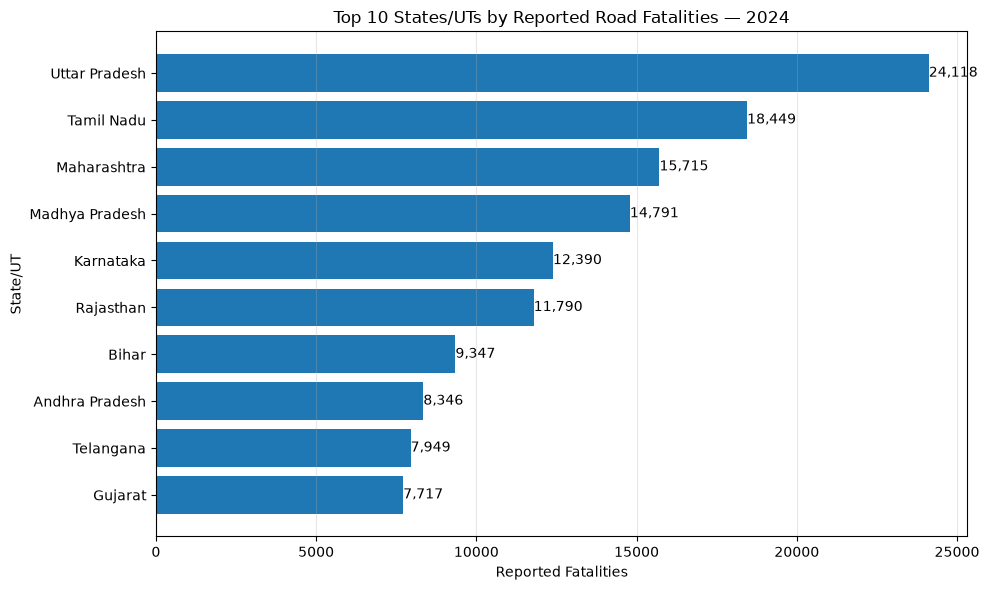

In [18]:
top_fatalities = (
    fatality_count_ranking
    .head(10)
    .iloc[::-1]
)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    top_fatalities["state"],
    top_fatalities["2024_killed"]
)

plt.title(
    "Top 10 States/UTs by Reported Road Fatalities — 2024"
)

plt.xlabel("Reported Fatalities")
plt.ylabel("State/UT")

for bar in bars:
    value = bar.get_width()

    plt.text(
        value,
        bar.get_y() + bar.get_height() / 2,
        f"{value:,.0f}",
        va="center",
        ha="left"
    )

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

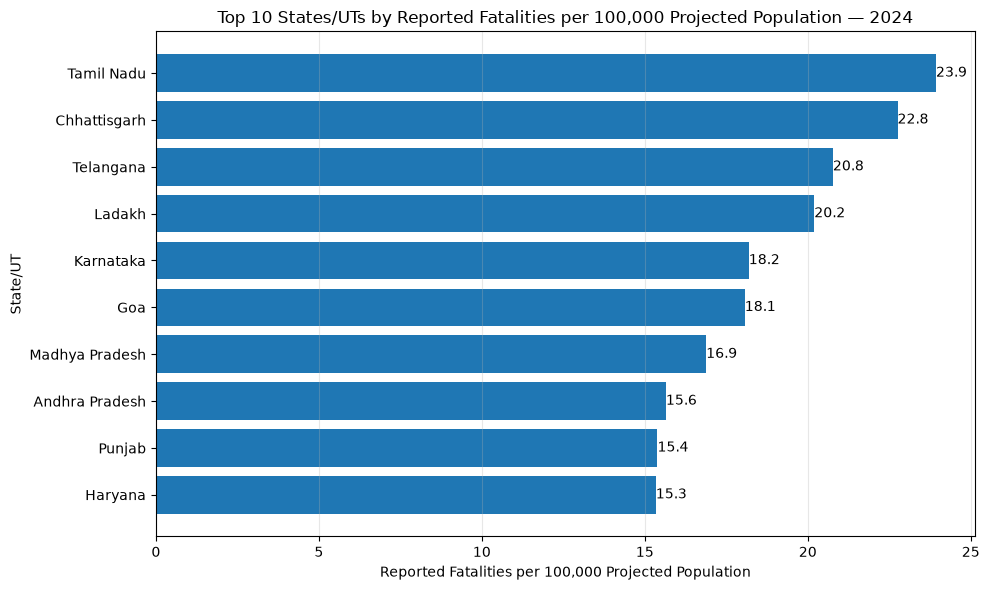

In [19]:
top_fatality_rates = (
    fatality_rate_ranking
    .head(10)
    .iloc[::-1]
)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    top_fatality_rates["state"],
    top_fatality_rates[
        "fatalities_per_100k_population"
    ]
)

plt.title(
    "Top 10 States/UTs by Reported Fatalities per "
    "100,000 Projected Population — 2024"
)

plt.xlabel(
    "Reported Fatalities per 100,000 Projected Population"
)

plt.ylabel("State/UT")

for bar in bars:
    value = bar.get_width()

    plt.text(
        value,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.1f}",
        va="center",
        ha="left"
    )

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

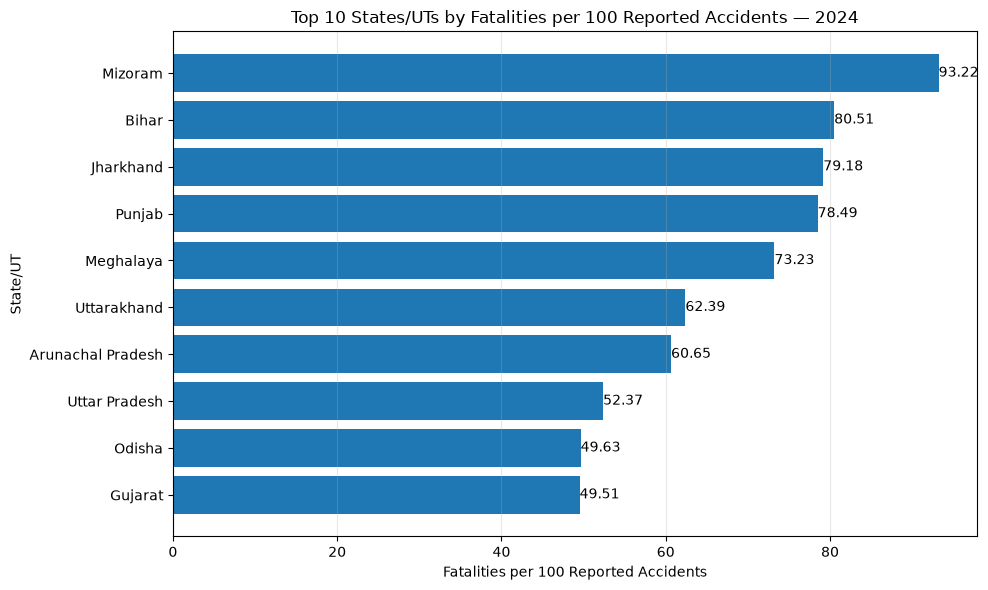

In [20]:
top_severity = (
    severity_ranking
    .head(10)
    .iloc[::-1]
)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    top_severity["state"],
    top_severity["fatalities_per_100_accidents"]
)

plt.title(
    "Top 10 States/UTs by Fatalities per 100 Reported Accidents — 2024"
)

plt.xlabel("Fatalities per 100 Reported Accidents")
plt.ylabel("State/UT")

for bar in bars:
    value = bar.get_width()

    plt.text(
        value,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.2f}",
        va="center",
        ha="left"
    )

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

In [21]:
comparison = fatality_analysis[
    [
        "state",
        "2024_accidents",
        "2024_killed",
        "fatalities_per_100k_population"
    ]
].copy()

comparison["accident_rank"] = (
    comparison["2024_accidents"]
    .rank(
        ascending=False,
        method="min"
    )
)

comparison["fatality_rank"] = (
    comparison["2024_killed"]
    .rank(
        ascending=False,
        method="min"
    )
)

comparison["rank_difference"] = (
    comparison["accident_rank"]
    - comparison["fatality_rank"]
)

display(
    comparison.sort_values(
        "rank_difference",
        key=abs,
        ascending=False
    )
)

,state,2024_accidents,2024_killed,fatalities_per_100k_population,accident_rank,fatality_rank,rank_difference
11,Kerala,48834.0,3880,10.801782,3.0,17.0,-14.0
3,Bihar,11610.0,9347,7.268726,14.0,7.0,7.0
16,Mizoram,118.0,110,8.800000,34.0,28.0,6.0
14,Manipur,299.0,72,2.213342,26.0,30.0,-4.0
31,Jammu & Kashmir,5808.0,831,6.065251,18.0,22.0,-4.0
32,Ladakh,264.0,61,20.198675,29.0,33.0,-4.0
9,Jharkhand,5196.0,4114,10.294522,20.0,16.0,4.0
26,Uttar Pradesh,46052.0,24118,10.130293,4.0,1.0,3.0
19,Punjab,6063.0,4759,15.388346,17.0,14.0,3.0
25,Uttarakhand,1747.0,1090,9.272650,23.0,20.0,3.0


In [22]:
fatality_output_path = (
    "../data/processed/"
    "state_fatality_analysis_2024.csv"
)

fatality_analysis.to_csv(
    fatality_output_path,
    index=False
)

print("Fatality analysis dataset saved:")
print(fatality_output_path)

Fatality analysis dataset saved:
../data/processed/state_fatality_analysis_2024.csv


In [23]:
verification_df = pd.read_csv(
    fatality_output_path
)

print("Verification successful.")

print(
    f"Rows: {verification_df.shape[0]}"
)

print(
    f"Columns: {verification_df.shape[1]}"
)

display(verification_df.head())

Verification successful.
Rows: 35
Columns: 6


,state,2024_accidents,2024_killed,population_2024,fatalities_per_100k_population,fatalities_per_100_accidents
0,Andhra Pradesh,19557.0,8346,53340000,15.646794,42.675257
1,Arunachal Pradesh,277.0,168,1576000,10.659898,60.649819
2,Assam,7848.0,3351,36047000,9.296197,42.698777
3,Bihar,11610.0,9347,128592000,7.268726,80.508183
4,Chhattisgarh,14857.0,6945,30524000,22.752588,46.745642


## Fatality Analysis — Initial Findings

Fatality data provides a different perspective from accident counts alone.

The analysis considers three complementary measures:

1. Absolute reported fatalities.
2. Reported fatalities per 100,000 projected population.
3. Reported fatalities per 100 reported accidents.

Absolute fatality counts identify States/UTs with the largest number of
reported deaths.

Population-normalized fatalities provide a comparison relative to projected
population size.

Fatalities per 100 reported accidents provide a measure of the reported
fatality burden relative to the number of reported accidents.

None of these measures alone represents complete road-accident risk.
Differences in traffic exposure, road usage, vehicle ownership, road
conditions, reporting practices and other factors can influence the observed
values.

The results should therefore be interpreted as descriptive indicators of
reported fatality burden rather than causal measures of road safety.

## Key Findings

The fatality analysis reveals that accident burden and fatality burden are
not equivalent.

Uttar Pradesh recorded the highest absolute number of reported road
fatalities in 2024, with 24,118 fatalities, while Tamil Nadu recorded the
highest number of reported accidents.

When fatalities are normalized by projected population, Tamil Nadu ranks
highest among the State/UT records analyzed, followed by Chhattisgarh and
Telangana.

The metric "fatalities per 100 reported accidents" produces yet another
ranking. Mizoram has the highest value according to this metric, followed by
Bihar and Jharkhand.

These three perspectives measure different aspects of the road-safety
problem and should not be treated as interchangeable.

Fatalities per 100 reported accidents should not be interpreted as the
probability that an individual involved in an accident will die, because the
denominator represents reported accidents rather than people involved in
those accidents.

Similarly, fatalities per 100,000 projected population represents a
population-normalized fatality burden rather than complete road-traffic risk.